# Tutorial 2 — Joint NMF + autoencoder

This notebook trains the joint model end-to-end and uses
the resulting 2-D embedding for visualization. Useful when
the downstream task is plotting / clustering rather than
interpreting the W/H factors directly.

We keep the run short (10 epochs) so the notebook executes
in under a minute on CPU. Production runs typically use
100+ epochs and a CUDA device.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
torch.manual_seed(0)
np.random.seed(0)

from sparse_nmf import train_joint_model
from sparse_nmf.data import generate_synthetic_sparse

X = generate_synthetic_sparse(
    n_samples=600, n_features=800, n_components=8,
    density=0.05, seed=0,
)
print(f'shape={X.shape}  nnz={X.nnz:,}')

shape=(600, 800)  nnz=24,001


## Train

`nmf_components` is the dimensionality of the NMF stage's
output (the autoencoder's input). `latent_dim` is the
bottleneck size — pick 2 for visualization, 64-256 for
downstream retrieval.

In [2]:
z, model = train_joint_model(
    X,
    n_samples=X.shape[0],
    n_features=X.shape[1],
    nmf_components=32,
    latent_dim=2,
    device='cpu',
    n_epochs=10,
    batch_size=128,
    verbose=False,
)
z = np.asarray(z)
print(f'embedding shape: {z.shape}')
print(f'mean={z.mean():.3f}  std={z.std():.3f}')

/Users/bschilder/Desktop/sparseNMF/src/sparse_nmf/_core.py:1701: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  X_sparse_torch = torch.sparse_coo_tensor(


embedding shape: (600, 2)
mean=0.396  std=0.057


## Plot the 2-D embedding

Color samples by the dominant factor in the synthetic
data — i.e. which of the 8 planted clusters they came
from. We compute the assignment from the original W (per-
sample mixture weights) so the colors reflect biology, not
the model's prediction.

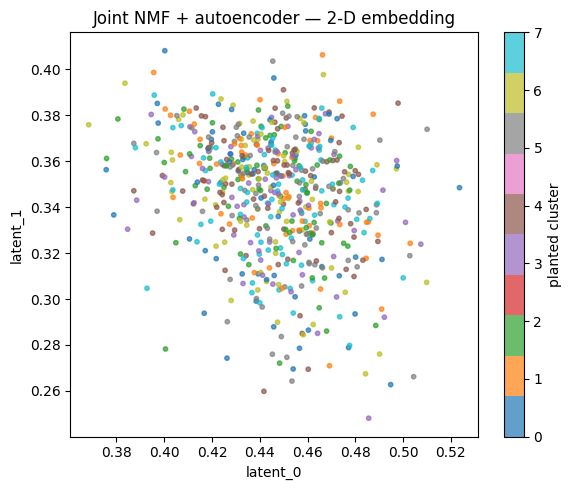

In [3]:
# Recover the planted cluster assignment for coloring.
rng = np.random.default_rng(0)
W_planted = rng.gamma(2.0, 1.0, (X.shape[0], 8)).astype(np.float32)
labels = W_planted.argmax(axis=1)

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(z[:, 0], z[:, 1], c=labels, cmap='tab10', s=10, alpha=0.7)
ax.set_xlabel('latent_0')
ax.set_ylabel('latent_1')
ax.set_title('Joint NMF + autoencoder — 2-D embedding')
plt.colorbar(scatter, ax=ax, label='planted cluster')
plt.tight_layout()
plt.show()

Even after only 10 epochs on CPU, the embedding shows
structure that lines up with the planted clusters. With
more epochs and real data, this becomes the input to
downstream tasks — clustering, retrieval, classification.